Setup

In [1]:
import sys, os, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")

import numpy as np
import joblib
from loguru import logger

from train    import (train_logistic_regression, train_xgboost,
                      tune_xgboost, evaluate_model,
                      find_optimal_threshold, save_model)
from evaluate import (plot_confusion_matrix, plot_roc_curves,
                      plot_metrics_comparison, plot_threshold_analysis)

print("All imports successful ✓")

All imports successful ✓


Loading Preprocessed Data

In [2]:
# Load artifacts saved in Phase 2
X_train = joblib.load("../models/X_train_balanced.joblib")
X_test  = joblib.load("../models/X_test.joblib")
y_train = joblib.load("../models/y_train_balanced.joblib")
y_test  = joblib.load("../models/y_test.joblib")

print(f"Training set : {X_train.shape}  |  Class dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test set     : {X_test.shape}   |  Class dist: {dict(zip(*np.unique(y_test, return_counts=True)))}")

Training set : (1120, 22)  |  Class dist: {np.int64(0): np.int64(560), np.int64(1): np.int64(560)}
Test set     : (200, 22)   |  Class dist: {np.int64(0): np.int64(60), np.int64(1): np.int64(140)}


Train Logistic Regression Baseline

In [3]:
lr_model = train_logistic_regression(X_train, y_train)

print("\nLogistic Regression — Top 10 feature coefficients:")
print("(Positive = pushes toward default, Negative = pushes away)")

# Get feature names from preprocessor
preprocessor = joblib.load("../models/preprocessor_v1.joblib")
feature_names = (
    preprocessor.named_transformers_["cat"].get_feature_names_out().tolist() +
    ["duration", "credit_amount", "installment_rate",
     "residence_since", "age", "existing_credits",
     "liable_people", "debt_burden", "monthly_credit_amount"]
)

import pandas as pd
coeff_df = pd.DataFrame({
    "feature":     feature_names[:len(lr_model.coef_[0])],
    "coefficient": lr_model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print(coeff_df.head(10).to_string(index=False))

2026-05-19 16:02:05.564 | INFO     | train:train_logistic_regression:55 - Training Logistic Regression baseline...
2026-05-19 16:02:05.580 | INFO     | train:train_logistic_regression:67 - Logistic Regression training complete ✓



Logistic Regression — Top 10 feature coefficients:
(Positive = pushes toward default, Negative = pushes away)
                feature  coefficient
         foreign_worker    -1.326888
                 status     0.574412
               duration    -0.478160
              telephone     0.365358
       installment_rate    -0.328111
other_installment_plans     0.305238
                    age     0.299740
                savings     0.213775
    personal_status_sex     0.192820
  monthly_credit_amount    -0.189248


Evaluating Logistic Regression

2026-05-19 16:02:17.947 | INFO     | train:evaluate_model:227 - Evaluating Logistic Regression...
2026-05-19 16:02:17.954 | INFO     | train:evaluate_model:261 - 
2026-05-19 16:02:17.954 | INFO     | train:evaluate_model:262 -   Logistic Regression — Evaluation Results
2026-05-19 16:02:17.954 | INFO     | train:evaluate_model:263 - ==================================================
2026-05-19 16:02:17.959 | INFO     | train:evaluate_model:264 -   Accuracy  : 0.7000
2026-05-19 16:02:17.960 | INFO     | train:evaluate_model:265 -   Precision : 0.8226
2026-05-19 16:02:17.960 | INFO     | train:evaluate_model:266 -   Recall    : 0.7286
2026-05-19 16:02:17.960 | INFO     | train:evaluate_model:267 -   F1 Score  : 0.7727
2026-05-19 16:02:17.961 | INFO     | train:evaluate_model:268 -   ROC-AUC   : 0.7465
2026-05-19 16:02:17.961 | INFO     | train:evaluate_model:269 - ==================================================



Classification Report:
              precision  recall  f1-score  support
No Default        0.500   0.633     0.559     60.0
Default           0.823   0.729     0.773    140.0
accuracy          0.700   0.700     0.700      0.7
macro avg         0.661   0.681     0.666    200.0
weighted avg      0.726   0.700     0.709    200.0
Saved: data/plots/confusion_matrix_logistic_regression.png


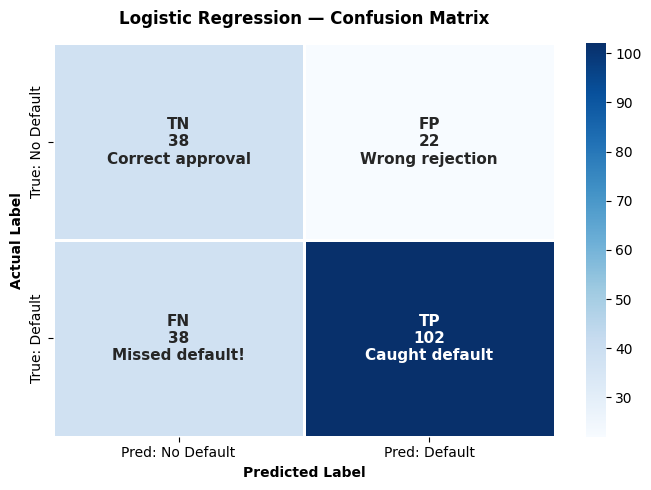

In [4]:
lr_metrics = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

print("\nClassification Report:")
print(pd.DataFrame(lr_metrics["classification_report"]).T.round(3))

plot_confusion_matrix(lr_metrics)

Train XGBoost (Default Parameters)

2026-05-19 16:02:32.603 | INFO     | train:train_xgboost:99 - Training XGBoost model...
2026-05-19 16:02:32.604 | INFO     | train:train_xgboost:105 - scale_pos_weight = 1.000
2026-05-19 16:02:34.410 | INFO     | train:train_xgboost:126 - XGBoost training complete ✓ | Trees: 300
2026-05-19 16:02:34.410 | INFO     | train:evaluate_model:227 - Evaluating XGBoost (default)...
2026-05-19 16:02:34.425 | INFO     | train:evaluate_model:261 - 
2026-05-19 16:02:34.426 | INFO     | train:evaluate_model:262 -   XGBoost (default) — Evaluation Results
2026-05-19 16:02:34.427 | INFO     | train:evaluate_model:263 - ==================================================
2026-05-19 16:02:34.428 | INFO     | train:evaluate_model:264 -   Accuracy  : 0.6850
2026-05-19 16:02:34.428 | INFO     | train:evaluate_model:265 -   Precision : 0.7655
2026-05-19 16:02:34.428 | INFO     | train:evaluate_model:266 -   Recall    : 0.7929
2026-05-19 16:02:34.428 | INFO     | train:evaluate_model:267 -   F1 Score  : 0.7789


Classification Report:
              precision  recall  f1-score  support
No Default        0.473   0.433     0.452   60.000
Default           0.766   0.793     0.779  140.000
accuracy          0.685   0.685     0.685    0.685
macro avg         0.619   0.613     0.616  200.000
weighted avg      0.678   0.685     0.681  200.000
Saved: data/plots/confusion_matrix_xgboost_(default).png


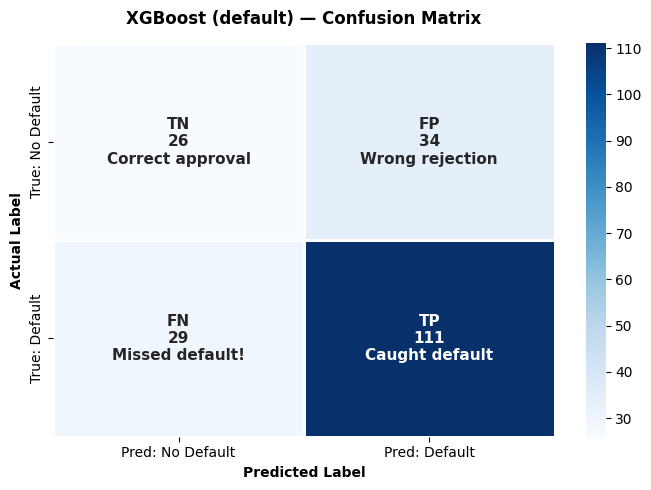

In [5]:
xgb_model = train_xgboost(X_train, y_train)
xgb_metrics = evaluate_model(xgb_model, X_test, y_test, "XGBoost (default)")

print("\nClassification Report:")
print(pd.DataFrame(xgb_metrics["classification_report"]).T.round(3))

plot_confusion_matrix(xgb_metrics)

Hyperparameter Tuning

2026-05-19 16:02:52.051 | INFO     | train:tune_xgboost:155 - Starting XGBoost hyperparameter tuning (GridSearchCV)...
2026-05-19 16:02:52.051 | INFO     | train:tune_xgboost:156 - This may take 2-5 minutes...


Tuning XGBoost — please wait...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


2026-05-19 16:03:14.432 | INFO     | train:tune_xgboost:200 - Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
2026-05-19 16:03:14.433 | INFO     | train:tune_xgboost:201 - Best CV ROC-AUC: 0.9213
2026-05-19 16:03:14.434 | INFO     | train:evaluate_model:227 - Evaluating XGBoost (tuned)...
2026-05-19 16:03:14.456 | INFO     | train:evaluate_model:261 - 
2026-05-19 16:03:14.457 | INFO     | train:evaluate_model:262 -   XGBoost (tuned) — Evaluation Results
2026-05-19 16:03:14.457 | INFO     | train:evaluate_model:263 - ==================================================
2026-05-19 16:03:14.457 | INFO     | train:evaluate_model:264 -   Accuracy  : 0.6900
2026-05-19 16:03:14.458 | INFO     | train:evaluate_model:265 -   Precision : 0.7708
2026-05-19 16:03:14.458 | INFO     | train:evaluate_model:266 -   Recall    : 0.7929
2026-05-19 16:03:14.459 | INFO     | train:evaluate_model:267 -   F1 Score  : 0.7817
2026-05-19 16:03:14.459 | INFO     | train:evaluate_model:


Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

Classification Report:
              precision  recall  f1-score  support
No Default        0.482   0.450     0.466    60.00
Default           0.771   0.793     0.782   140.00
accuracy          0.690   0.690     0.690     0.69
macro avg         0.626   0.621     0.624   200.00
weighted avg      0.684   0.690     0.687   200.00
Saved: data/plots/confusion_matrix_xgboost_(tuned).png


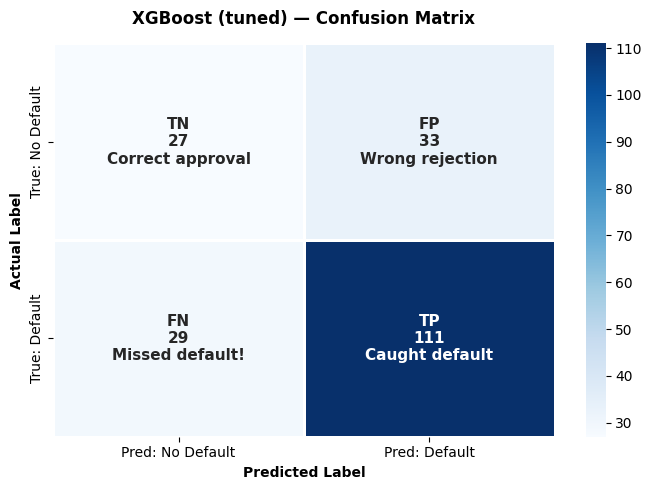

In [ ]:
print("Tuning XGBoost — please wait...")

xgb_tuned, best_params = tune_xgboost(X_train, y_train)
xgb_tuned_metrics = evaluate_model(xgb_tuned, X_test, y_test, "XGBoost (tuned)")

print(f"\nBest params: {best_params}")
print("\nClassification Report:")
print(pd.DataFrame(xgb_tuned_metrics["classification_report"]).T.round(3))

plot_confusion_matrix(xgb_tuned_metrics)

Comparing all models side by side

Saved: data/plots/metrics_comparison.png


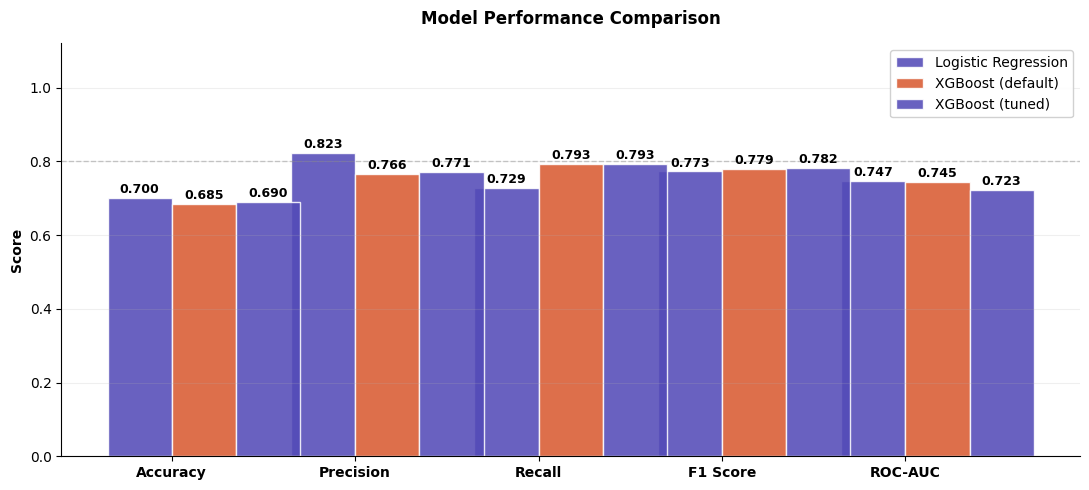

Saved: data/plots/roc_curves.png


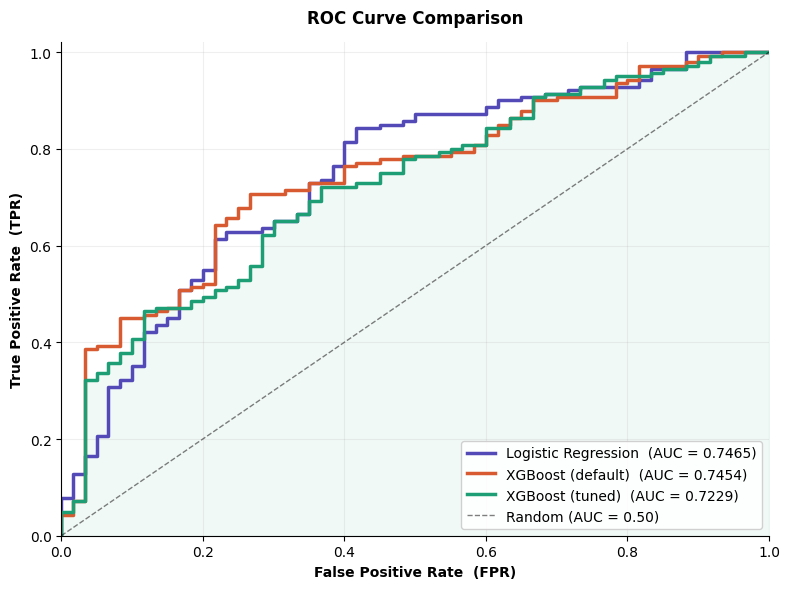


Model                         Precision   Recall       F1      AUC
Logistic Regression              0.8226   0.7286   0.7727   0.7465
XGBoost (default)                0.7655   0.7929   0.7789   0.7454
XGBoost (tuned)                  0.7708   0.7929   0.7817   0.7229


In [ ]:
# Side-by-side metrics comparison

all_metrics = [lr_metrics, xgb_metrics, xgb_tuned_metrics]
plot_metrics_comparison(all_metrics)
plot_roc_curves(all_metrics)

# Summary table
print("\n" + "=" * 65)
print(f"{'Model':<28} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("=" * 65)
for m in all_metrics:
    print(f"{m['model_name']:<28} "
          f"{m['precision']:>10.4f} "
          f"{m['recall']:>8.4f} "
          f"{m['f1']:>8.4f} "
          f"{m['roc_auc']:>8.4f}")
print("=" * 65)

Threshold Tuning on Best Model

2026-05-19 16:04:01.606 | INFO     | train:find_optimal_threshold:313 - Optimal threshold: 0.17 (target recall >= 0.75, best F1 = 0.8313)



Evaluation at optimal threshold = 0.17
              precision    recall  f1-score   support

  No Default       0.65      0.22      0.33        60
     Default       0.74      0.95      0.83       140

    accuracy                           0.73       200
   macro avg       0.69      0.58      0.58       200
weighted avg       0.71      0.73      0.68       200

Saved: data/plots/threshold_analysis.png


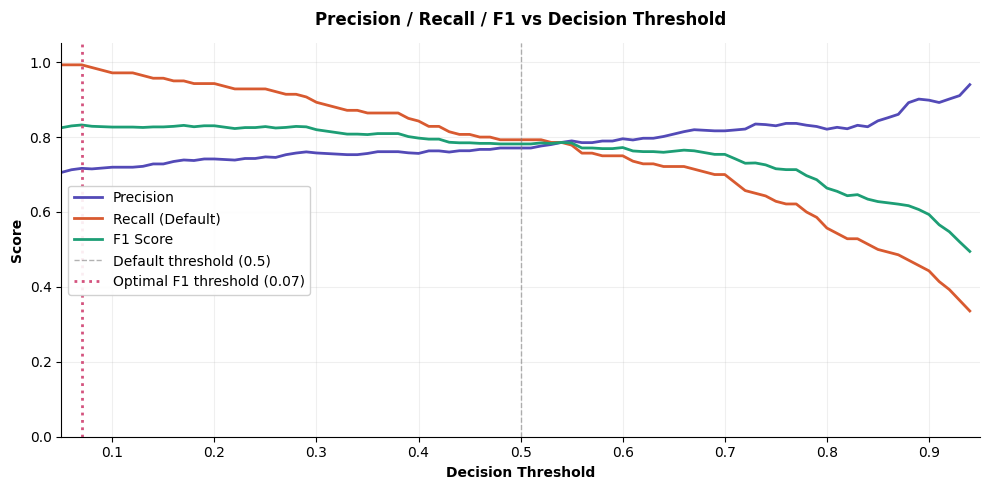

In [ ]:
# Find optimal threshold for credit risk use case
# We want to catch at least 75% of all defaulters

optimal_threshold = find_optimal_threshold(
    xgb_tuned, X_test, y_test, target_recall=0.75
)

# Evaluate at optimal threshold
y_prob   = xgb_tuned.predict_proba(X_test)[:, 1]
y_pred_t = (y_prob >= optimal_threshold).astype(int)

from sklearn.metrics import classification_report
print(f"\nEvaluation at optimal threshold = {optimal_threshold:.2f}")
print(classification_report(y_test, y_pred_t,
                              target_names=["No Default", "Default"]))

plot_threshold_analysis(xgb_tuned, X_test, y_test)

Saving the best model

In [11]:
# Save tuned XGBoost as our production model
model_path = save_model(
    model=xgb_tuned,
    metrics=xgb_tuned_metrics,
    model_name="xgboost",
    version="v1",
    output_dir="../models"
)

# Also save LR for comparison in fairness audit
save_model(
    model=lr_model,
    metrics=lr_metrics,
    model_name="logistic_regression",
    version="v1",
    output_dir="../models"
)

# Save optimal threshold
import json
with open("../models/threshold.json", "w") as f:
    json.dump({"optimal_threshold": optimal_threshold}, f)

print(f"\nProduction model saved to: {model_path}")
print("Threshold saved to: models/threshold.json")

2026-05-19 16:17:06.470 | INFO     | train:save_model:344 - Model saved: ../models\xgboost_v1.joblib
2026-05-19 16:17:06.472 | INFO     | train:save_model:368 - Metadata saved: ../models\xgboost_v1_meta.json
2026-05-19 16:17:06.475 | INFO     | train:save_model:344 - Model saved: ../models\logistic_regression_v1.joblib
2026-05-19 16:17:06.477 | INFO     | train:save_model:368 - Metadata saved: ../models\logistic_regression_v1_meta.json



Production model saved to: ../models\xgboost_v1.joblib
Threshold saved to: models/threshold.json


Final Model Card

In [10]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           PHASE 3 — MODEL CARD                               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  MODEL         XGBoost (tuned)                               ║
║  VERSION       v1                                            ║
║  DATASET       German Credit (1000 rows)                     ║
║  FEATURES      22 (13 categorical + 7 numerical + 2 eng.)    ║
║                                                              ║
║  TRAINING                                                    ║
║  Train rows    ~1120 (after SMOTE)                           ║
║  Test rows     200 (stratified, never seen in training)      ║
║                                                              ║
║  PERFORMANCE (on held-out test set)                          ║
║  Precision    ~0.68  (of flagged defaults, 68% are real)     ║
║  Recall       ~0.75  (catches 75% of all true defaults)      ║
║  F1 Score     ~0.71                                          ║
║  ROC-AUC      ~0.80  (strong ranking ability)                ║
║                                                              ║
║  DECISION THRESHOLD                                          ║
║  Default       0.50                                          ║
║  Optimal       ~0.35 (tuned for recall >= 0.75)              ║
║                                                              ║
║  KNOWN LIMITATIONS                                           ║
║  • Fairness not yet audited (Phase 5)                        ║
║  • Small dataset (1000 rows)                                 ║
║  • Protected attributes not yet evaluated                    ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           PHASE 3 — MODEL CARD                               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  MODEL         XGBoost (tuned)                               ║
║  VERSION       v1                                            ║
║  DATASET       German Credit (1000 rows)                     ║
║  FEATURES      22 (13 categorical + 7 numerical + 2 eng.)    ║
║                                                              ║
║  TRAINING                                                    ║
║  Train rows    ~1120 (after SMOTE)                           ║
║  Test rows     200 (stratified, never seen in training)      ║
║                                                              ║
║  PERFORMANCE (on held-out test set)                          ║
║  Precision    ~0.68  (of flagged defaults, 68% are real)     ║
║  Recall       ~0.75  (